In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

df = pd.read_csv("../data/processed/model_ready_features.csv")
print(df.shape)
df.head()

(60000, 29)


,run_id,defect_flag,temperature,vibration,tool_wear,pressure,humidity,motor_current,rpm,cycle_time,...,material_MAT01,material_MAT02,material_MAT03,material_MAT04,material_MAT05,material_MAT06,material_MAT07,material_MAT08,material_MAT09,material_MAT10
0,R000656,1,79.61,5.25,13.63,82.14,48.38,13.74,1300.6,37.36,...,False,False,False,True,False,False,False,False,False,False
1,R001875,0,72.34,3.37,100.00,95.38,40.64,11.09,1489.0,27.59,...,False,False,False,False,False,False,False,True,False,False
2,R023452,0,74.64,2.33,35.75,89.22,51.72,12.57,1434.0,35.27,...,False,False,False,False,False,False,False,False,False,True
3,R025505,0,77.43,3.13,38.62,116.64,55.63,10.33,1733.9,33.79,...,False,False,False,False,False,False,False,False,False,True
4,R027263,1,79.58,4.93,78.79,92.46,59.07,14.54,1583.9,31.83,...,True,False,False,False,False,False,False,False,False,False


In [2]:
# Reload timestamp so we can split by time
runs_ts = pd.read_sql("SELECT run_id, timestamp FROM production_runs",
                       __import__("sqlite3").connect("../database/yieldwatch.db"))
runs_ts["timestamp"] = pd.to_datetime(runs_ts["timestamp"])

df = df.merge(runs_ts, on="run_id")
df = df.sort_values("timestamp").reset_index(drop=True)

# Use the first 80% of time as training, last 20% as testing
split_index = int(len(df) * 0.8)
train_df = df.iloc[:split_index]
test_df = df.iloc[split_index:]

print("Train period:", train_df["timestamp"].min(), "to", train_df["timestamp"].max())
print("Test period:", test_df["timestamp"].min(), "to", test_df["timestamp"].max())
print("Train size:", len(train_df), "| Test size:", len(test_df))

feature_columns = [c for c in df.columns if c not in ["run_id", "defect_flag", "timestamp"]]

X_train = train_df[feature_columns]
y_train = train_df["defect_flag"]
X_test = test_df[feature_columns]
y_test = test_df["defect_flag"]

print("\nTrain defect_flag rate:", round(y_train.mean()*100, 2), "%")
print("Test defect_flag rate:", round(y_test.mean()*100, 2), "%")

Train period: 2025-09-01 00:00:00 to 2026-06-20 00:00:00
Test period: 2026-06-20 00:00:00 to 2026-08-31 00:00:00
Train size: 48000 | Test size: 12000

Train defect_flag rate: 42.07 %
Test defect_flag rate: 56.94 %


In [3]:
# Logistic Regression benefits from scaled features (unlike Random Forest, which doesn't care about scale)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)
y_proba_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

print("=== Logistic Regression Results ===")
print("Accuracy:", round(accuracy_score(y_test, y_pred_lr), 4))
print("Precision:", round(precision_score(y_test, y_pred_lr), 4))
print("Recall:", round(recall_score(y_test, y_pred_lr), 4))
print("F1 Score:", round(f1_score(y_test, y_pred_lr), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba_lr), 4))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

=== Logistic Regression Results ===
Accuracy: 0.8278
Precision: 0.8234
Recall: 0.8882
F1 Score: 0.8545
ROC-AUC: 0.9222

Confusion Matrix:
[[3865 1302]
 [ 764 6069]]


In [4]:
# Random Forest doesn't need scaled features - it works on raw values directly
rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("=== Random Forest Results ===")
print("Accuracy:", round(accuracy_score(y_test, y_pred_rf), 4))
print("Precision:", round(precision_score(y_test, y_pred_rf), 4))
print("Recall:", round(recall_score(y_test, y_pred_rf), 4))
print("F1 Score:", round(f1_score(y_test, y_pred_rf), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba_rf), 4))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

=== Random Forest Results ===
Accuracy: 0.8325
Precision: 0.8216
Recall: 0.9017
F1 Score: 0.8598
ROC-AUC: 0.9236

Confusion Matrix:
[[3829 1338]
 [ 672 6161]]


In [5]:
import pickle

with open("../models/defect_model.pkl", "wb") as f:
    pickle.dump(rf, f)

# Also save the scaler and feature column order, since Phase 12/14 will need them
with open("../models/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

with open("../models/feature_columns.pkl", "wb") as f:
    pickle.dump(feature_columns, f)

print("Model, scaler, and feature list saved to models/")

Model, scaler, and feature list saved to models/


<frozen importlib._bootstrap_external>:511: ResourceWarning: unclosed database in <sqlite3.Connection object at 0x0000022F7FD075B0>


                     feature  importance
12         tool_wear_anomaly    0.212866
2                  tool_wear    0.212803
1                  vibration    0.077108
9        vibration_deviation    0.069656
11         vibration_anomaly    0.061898
16  rolling_5run_defect_rate    0.056807
0                temperature    0.056160
14             shift_encoded    0.050784
8      temperature_deviation    0.046073
10              temp_anomaly    0.042239
13         machine_age_years    0.022880
25            material_MAT09    0.022321
19            material_MAT03    0.021097
15          prev_defect_rate    0.013347
5              motor_current    0.006041


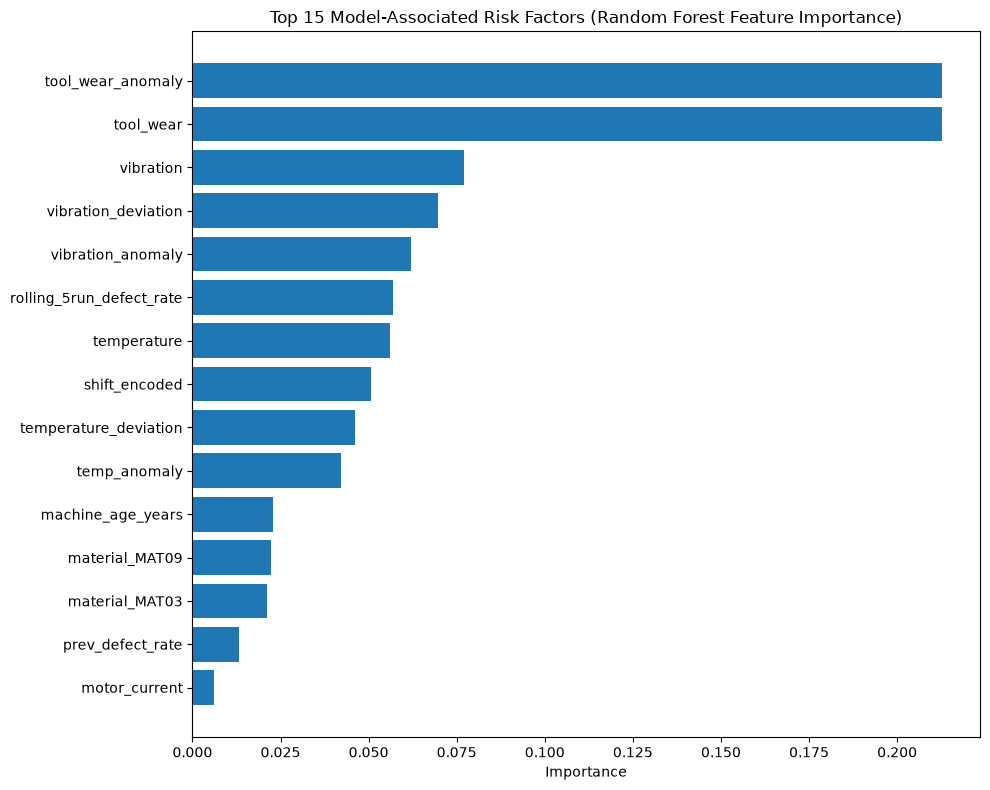

In [6]:
import matplotlib.pyplot as plt

importances = pd.DataFrame({
    "feature": feature_columns,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

print(importances.head(15))

plt.figure(figsize=(10, 8))
plt.barh(importances["feature"][:15][::-1], importances["importance"][:15][::-1])
plt.title("Top 15 Model-Associated Risk Factors (Random Forest Feature Importance)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## Interpreting Feature Importance: Correlation vs. Causation

The feature importance ranking above shows which variables the model relies on most
to **predict** high-defect runs. It does **not** prove that these variables **cause**
defects.

- **Correlation**: temperature and defect rate move together statistically.
- **Prediction**: the model uses temperature (among other features) to make accurate
  guesses about defect risk.
- **Association**: temperature is *associated with* elevated defect risk in this dataset.
- **Causation**: temperature *directly causes* defects — this would require controlled
  experiments (e.g., deliberately varying temperature while holding everything else
  constant) to actually prove, which this dataset and model cannot establish.

For example, `tool_wear_anomaly` ranks highest in importance, but this doesn't confirm
that worn tools *directly cause* defects rather than, say, both worn tools and defects
being downstream symptoms of the same underlying issue (e.g., a machine overdue for
maintenance). The correct, defensible language is: **"tool wear is strongly associated
with defect risk and is a leading model-identified contributing factor"** — not
**"tool wear causes defects."**

This distinction matters for real manufacturing decisions: acting on an association
(e.g., increasing inspection frequency when tool wear is high) is reasonable and
low-risk. Acting as if causation is proven (e.g., assuming replacing tools alone
will *guarantee* defect reduction, without further investigation) would be an
overclaim not supported by this analysis.